### Imports

In [68]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [69]:
df = pd.read_csv("SMSSpamCollection", sep="\t", header=None, names=["label", "text"])
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"


### View Sample Messages

In [70]:
df.loc[0, "text"]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

### Another Sample

In [71]:
df.loc[1, "text"]

'Ok lar... Joking wif u oni...'

### Dataset Shape

In [72]:
df.shape

(5572, 2)

### Class Counts

In [73]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

### Class Percentage

In [74]:
df["label"].value_counts(normalize=True) * 100

label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64

### Missing Values

In [75]:
df.isnull().sum()

label    0
text     0
dtype: int64

### Class Distribution Bar Chart

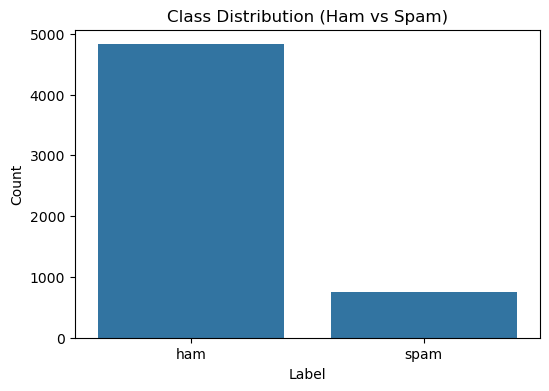

In [76]:
plt.figure(figsize=(6,4))
sns.countplot(x="label", data=df)
plt.title("Class Distribution (Ham vs Spam)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

### Text Cleaning

In [77]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)   # keep only letters + spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

### Apply Cleaning

In [78]:
df["clean_text"] = df["text"].apply(clean_text)
df[["label", "text", "clean_text"]].head()

,label,text,clean_text
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,free entry in a wkly comp to win fa cup final tkts st may text fa to to receive entry questionstd txt ratetcs apply overs
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives around here though",nah i dont think he goes to usf he lives around here though


In [79]:
df["clean_text"]

0                               go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat
1                                                                                                              ok lar joking wif u oni
2            free entry in a wkly comp to win fa cup final tkts st may text fa to to receive entry questionstd txt ratetcs apply overs
3                                                                                          u dun say so early hor u c already then say
4                                                                          nah i dont think he goes to usf he lives around here though
                                                                     ...                                                              
5567    this is the nd time we have tried contact u u have won the pound prize claim is easy call now only p per minute btnationalrate
5568                                                   

### Train/Test Split

In [80]:
X_text = df["clean_text"]
y = df["label"]

In [81]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_text.shape, X_test_text.shape

((4457,), (1115,))

### TF-IDF Vectorization

In [82]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english")
# TF-IDF with English stopwords removed (default settings for other parameters)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

X_train.shape, X_test.shape

((4457, 7269), (1115, 7269))

### MODEL 1: Naive Bayes

In [83]:
#Train + Evaluate Naive Bayes

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

nb = MultinomialNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report (Naive Bayes):\n")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9641255605381166

Classification Report (Naive Bayes):

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       1.00      0.73      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.87      0.91      1115
weighted avg       0.97      0.96      0.96      1115



### Naive Bayes Confusion Matrix

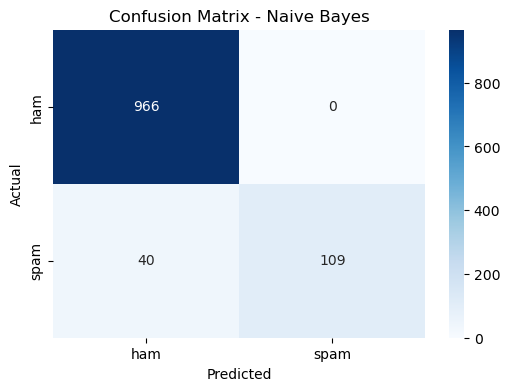

In [84]:
from sklearn.metrics import confusion_matrix

cm_nb = confusion_matrix(y_test, y_pred_nb, labels=["ham", "spam"])

plt.figure(figsize=(6,4))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues",
            xticklabels=["ham", "spam"],
            yticklabels=["ham", "spam"])
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### MODEL 2: Logistic Regression

In [85]:
#Train + Evaluate Logistic Regression

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report (Logistic Regression):\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9632286995515695

Classification Report (Logistic Regression):

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       1.00      0.72      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



### Logistic Regression Confusion Matrix


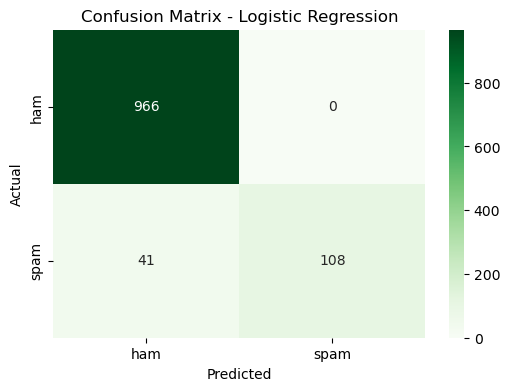

In [86]:
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=["ham", "spam"])

plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Greens",
            xticklabels=["ham", "spam"],
            yticklabels=["ham", "spam"])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### ROC + AUC + PR CURVE

In [87]:
#Probabilities + Binary Labels

y_test_binary = (y_test == "spam").astype(int)

y_proba_nb = nb.predict_proba(X_test)[:, 1]
y_proba_lr = lr.predict_proba(X_test)[:, 1]

Naive Bayes AUC: 0.9801
Logistic Regression AUC: 0.9832


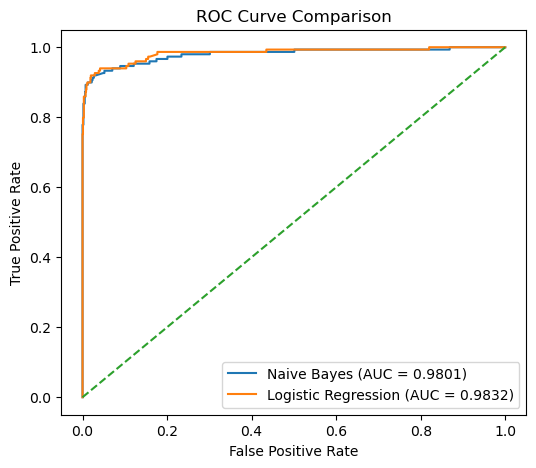

In [88]:
#ROC Curve + AUC 

from sklearn.metrics import roc_curve, auc

fpr_nb, tpr_nb, _ = roc_curve(y_test_binary, y_proba_nb)
auc_nb = auc(fpr_nb, tpr_nb)

fpr_lr, tpr_lr, _ = roc_curve(y_test_binary, y_proba_lr)
auc_lr = auc(fpr_lr, tpr_lr)

print("Naive Bayes AUC:", round(auc_nb, 4))
print("Logistic Regression AUC:", round(auc_lr, 4))

plt.figure(figsize=(6,5))
plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC = {auc_nb:.4f})")
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.4f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

### Precision-Recall Curve + AP

Naive Bayes AP: 0.9516
Logistic Regression AP: 0.956


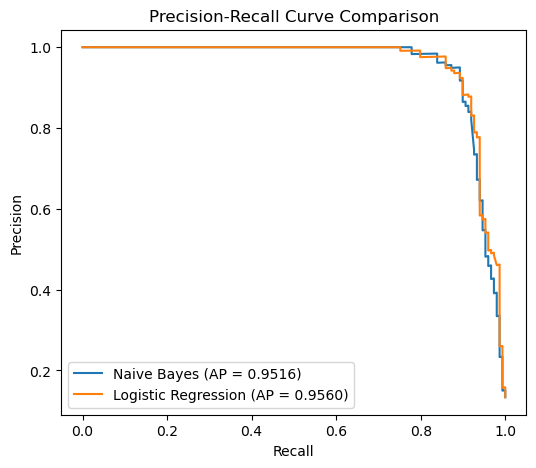

In [89]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_nb, recall_nb, _ = precision_recall_curve(y_test_binary, y_proba_nb)
ap_nb = average_precision_score(y_test_binary, y_proba_nb)

precision_lr, recall_lr, _ = precision_recall_curve(y_test_binary, y_proba_lr)
ap_lr = average_precision_score(y_test_binary, y_proba_lr)

print("Naive Bayes AP:", round(ap_nb, 4))
print("Logistic Regression AP:", round(ap_lr, 4))

plt.figure(figsize=(6,5))
plt.plot(recall_nb, precision_nb, label=f"Naive Bayes (AP = {ap_nb:.4f})")
plt.plot(recall_lr, precision_lr, label=f"Logistic Regression (AP = {ap_lr:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()

### Model Comparison Table

In [90]:
from sklearn.metrics import classification_report

report_nb = classification_report(y_test, y_pred_nb, output_dict=True)
report_lr = classification_report(y_test, y_pred_lr, output_dict=True)

comparison_df = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression"],
    "Accuracy": [report_nb["accuracy"], report_lr["accuracy"]],
    "Precision (Spam)": [report_nb["spam"]["precision"], report_lr["spam"]["precision"]],
    "Recall (Spam)": [report_nb["spam"]["recall"], report_lr["spam"]["recall"]],
    "F1-Score (Spam)": [report_nb["spam"]["f1-score"], report_lr["spam"]["f1-score"]],
    "AUC": [auc_nb, auc_lr],
    "AP": [ap_nb, ap_lr]
})

comparison_df

,Model,Accuracy,Precision (Spam),Recall (Spam),F1-Score (Spam),AUC,AP
0,Naive Bayes,0.964126,1.0,0.731544,0.844961,0.980105,0.951592
1,Logistic Regression,0.963229,1.0,0.724832,0.840467,0.983246,0.955974


### Top Spam Words (Logistic Regression)

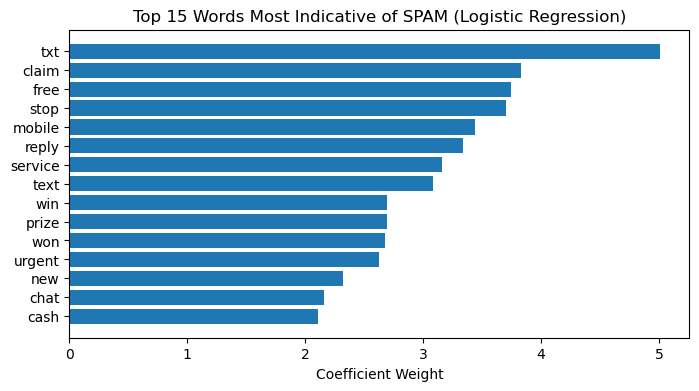

In [91]:
feature_names = np.array(vectorizer.get_feature_names_out())
coef = lr.coef_[0]

top_spam_idx = np.argsort(coef)[-15:]

plt.figure(figsize=(8,4))
plt.barh(feature_names[top_spam_idx], coef[top_spam_idx])
plt.title("Top 15 Words Most Indicative of SPAM (Logistic Regression)")
plt.xlabel("Coefficient Weight")
plt.show()

### Top Ham Words (Logistic Regression)

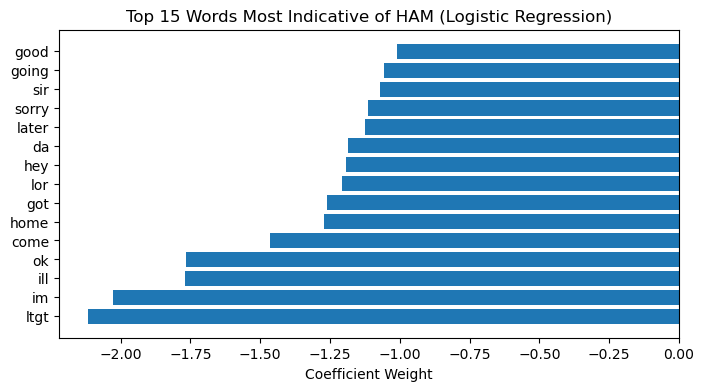

In [92]:
top_ham_idx = np.argsort(coef)[:15]

plt.figure(figsize=(8,4))
plt.barh(feature_names[top_ham_idx], coef[top_ham_idx])
plt.title("Top 15 Words Most Indicative of HAM (Logistic Regression)")
plt.xlabel("Coefficient Weight")
plt.show()

### Model In Action 

In [93]:
#Sample Messages List

sample_messages = [
    "Congratulations! You won a free prize. Call now!",
    "Hey, are we meeting tomorrow?",
    "Urgent! Your bank account is compromised. Click the link.",
    "Limited time offer! Get 50% discount today only!",
    "Don't forget to submit the assignment tonight.",
    "Exclusive deal just for you. Click to know more"
]

In [94]:
#Preprocess Sample Function

def preprocess_sample(text):
    return clean_text(text)

### Naive Bayes Predictions

In [95]:
print("Naive Bayes Predictions:\n")

sample_clean = [preprocess_sample(msg) for msg in sample_messages]
sample_vec = vectorizer.transform(sample_clean)

for msg, pred in zip(sample_messages, nb.predict(sample_vec)):
    print(f"Text: {msg}")
    print(f"Prediction: {pred}\n")

Naive Bayes Predictions:

Text: Congratulations! You won a free prize. Call now!
Prediction: spam

Text: Hey, are we meeting tomorrow?
Prediction: ham

Text: Urgent! Your bank account is compromised. Click the link.
Prediction: spam

Text: Limited time offer! Get 50% discount today only!
Prediction: ham

Text: Don't forget to submit the assignment tonight.
Prediction: ham

Text: Exclusive deal just for you. Click to know more
Prediction: ham



### Logistic Regression Predictions

In [96]:
print("Logistic Regression Predictions:\n")

for msg, pred in zip(sample_messages, lr.predict(sample_vec)):
    print(f"Text: {msg}")
    print(f"Prediction: {pred}\n")

Logistic Regression Predictions:

Text: Congratulations! You won a free prize. Call now!
Prediction: spam

Text: Hey, are we meeting tomorrow?
Prediction: ham

Text: Urgent! Your bank account is compromised. Click the link.
Prediction: ham

Text: Limited time offer! Get 50% discount today only!
Prediction: ham

Text: Don't forget to submit the assignment tonight.
Prediction: ham

Text: Exclusive deal just for you. Click to know more
Prediction: ham

